# All-slices 3D simulator with NB mean / dispersion intervention and time-varying $\mu(t)$

This notebook follows the saved-model simulation workflow

$$
\text{3D coordinates}
\rightarrow
\text{region labels}
\rightarrow
\text{cell-type labels}
\rightarrow
\text{NB parameter intervention}
\rightarrow
\text{time-varying gene expression}.
$$

The region and cell-type components are loaded from the saved models and are not manually altered. The baseline gene-expression model is loaded from the saved all-slice 3D negative-binomial model. The intervention is introduced only after the saved-model region and cell-type labels have been generated and before negative-binomial counts are sampled.

For cell $i$, gene $g$, and time $t$, the simulated count is parameterized using the NB2 form

$$
Y_{ig}(t)
\sim
\operatorname{NB}\!\left(\mu_{ig}(t),\alpha_{ig}(t)\right),
$$

with

$$
\operatorname{E}\!\left[Y_{ig}(t)\right]
=
\mu_{ig}(t),
\qquad
\operatorname{Var}\!\left[Y_{ig}(t)\right]
=
\mu_{ig}(t)
+
\alpha_{ig}(t)\mu_{ig}^{2}(t).
$$

Here, $\mu_{ig}(t)$ is the mean parameter and $\alpha_{ig}(t)>0$ is the overdispersion parameter. A larger value of $\alpha_{ig}(t)$ produces greater count variability at the same mean.

Under the saved baseline model,

$$
\log \mu_{ig}^{0}
=
\log L_i
+
X_i^\top \widehat\beta_g,
\qquad
\alpha_{ig}^{0}
=
\alpha_g,
$$

where $L_i$ is the library-size offset, $X_i$ is the design vector determined by the saved-model region and cell-type labels, $\widehat\beta_g$ is the fitted coefficient vector for gene $g$, and $\alpha_g$ is the fitted gene-specific baseline dispersion.

The time-varying mean intervention is defined by

$$
\log \mu_{ig}^{\mathrm{new}}(t)
=
\log \mu_{ig}^{0}
+
\Delta_{ig}(t),
$$

or equivalently,

$$
\mu_{ig}^{\mathrm{new}}(t)
=
\mu_{ig}^{0}\exp\!\left\{\Delta_{ig}(t)\right\}.
$$

Thus, $\Delta_{ig}(t)$ is a log-scale mean shift, and $\exp\{\Delta_{ig}(t)\}$ is the corresponding fold-change.

An optional time-varying dispersion intervention is defined by

$$
\alpha_{ig}^{\mathrm{new}}(t)
=
\alpha_g A_{ig}(t),
$$

where $A_{ig}(t)>0$ is a dispersion multiplier. In the implementation,

$$
A_{ig}(t)
=
\begin{cases}
 a_{\mathrm{final}}^{\,h(t)},
 & \text{if cell $i$ and gene $g$ satisfy the intervention rule},\\[4pt]
 1,
 & \text{otherwise},
\end{cases}
$$

where $a_{\mathrm{final}}$ is `final_alpha_multiplier` and $h(t)$ is the selected temporal pattern. Therefore, $A_{ig}(t)=1$ leaves the baseline dispersion unchanged, $A_{ig}(t)>1$ increases overdispersion, and $0<A_{ig}(t)<1$ decreases overdispersion without directly changing the mean.

Large mean fold-changes and dispersion multipliers are used by default so that the synthetic changes are visually obvious.

## 1. Import packages and specify simulation settings

This block defines the target section, saved-model paths, and the NB mean / dispersion intervention rules. Region labels and cell-type labels are generated from the saved models without any composition intervention. The static intervention is applied first. The time-series intervention is applied later using $\mu(t)$.


In [1]:
from pathlib import Path
import json
import re
import pickle
import joblib

import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import torch
import torch.nn as nn

from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors


def serialize_uns_metadata(value):
    """Serialize nested intervention settings into an HDF5-safe JSON string."""

    def json_default(obj):
        if isinstance(obj, np.generic):
            return obj.item()
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        raise TypeError(
            f"Object of type {type(obj).__name__} is not JSON serializable"
        )

    return json.dumps(
        value,
        ensure_ascii=False,
        default=json_default,
    )


TARGET_SLICE = "A6"
PLOT_GENE = "Nnat"
SEED = 20260623

# Match the categorical sampling seed used in cell_type_with_model_save.ipynb.
CELLTYPE_SAMPLING_SEED = 42

# Used only for virtual sections such as A5.5.
VIRTUAL_N_CELLS = 5000

# Static NB mean intervention.
# fold_change > 1 increases the NB mean; fold_change < 1 decreases the NB mean.
STATIC_MEAN_INTERVENTIONS = [
    {
        "genes": ["Nnat"],
        "celltype": "Ependymal",
        "region": "13.0",
        "fold_change": 10.0,
    },
    {
        "genes": ["Nnat"],
        "celltype": "Astrocyte",
        "region": "12.0",
        "fold_change": 0.05,
    },
]

# Static NB dispersion intervention.
# alpha_multiplier > 1 makes the sampled counts much more overdispersed.
STATIC_DISPERSION_INTERVENTIONS = [
    {
        "genes": ["Nnat"],
        "celltype": "Ependymal",
        "region": "13.0",
        "alpha_multiplier": 8.0,
    },
    {
        "genes": ["Nnat"],
        "celltype": "Astrocyte",
        "region": "12.0",
        "alpha_multiplier": 5.0,
    },
]

# Time grid for the dynamic mean parameter mu(t).
TIMES = np.array([0.0, 0.25, 0.5, 0.75, 1.0])

# Time-varying NB mean intervention.
# final_fold_change is reached approximately at t = 1.
TIME_MEAN_INTERVENTIONS = [
    {
        "genes": ["Nnat"],
        "celltype": "Ependymal",
        "region": "13.0",
        "final_fold_change": 12.0,
        "time_pattern": "sigmoid",
        "midpoint": 0.50,
        "sharpness": 12.0,
    },
    {
        "genes": ["Nnat"],
        "celltype": "Astrocyte",
        "region": "12.0",
        "final_fold_change": 0.03,
        "time_pattern": "linear",
    },
]

# Optional time-varying NB dispersion intervention.
TIME_DISPERSION_INTERVENTIONS = [
    {
        "genes": ["Nnat"],
        "celltype": "Ependymal",
        "region": "13.0",
        "final_alpha_multiplier": 8.0,
        "time_pattern": "linear",
    },
]

ADATA_PATH = Path("../adata_backup_with_pred_region_celltype.h5ad")
MODEL_DIR = Path("../saved_models")

DOMAIN_STATE = MODEL_DIR / "domain_mlp_state.pt"
DOMAIN_PREP = MODEL_DIR / "domain_preprocess.joblib"

CELLTYPE_STATE = MODEL_DIR / "celltype_mlp_state.pt"
CELLTYPE_PREP = MODEL_DIR / "celltype_preprocess.joblib"

GENE_MODEL = MODEL_DIR / "gene_fit_results_all_slices_3d.pkl"

OUT_DIR = (
    Path("All_slices_prediction_outputs")
    / f"{TARGET_SLICE}_nb_intervention_time_series_v2"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)


## 2. Define the saved neural-network architectures

The saved domain model maps standardized 3D coordinates to region scores. The saved cell-type model maps region-aware relative coordinates to cell-type probabilities.

In [2]:
class SpatialMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)


class SpatialProbMLP(nn.Module):
    def __init__(self, input_dim, n_celltypes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, n_celltypes),
        )

    def forward(self, x):
        return torch.softmax(self.net(x), dim=1)


def load_state(path):
    return torch.load(
        path,
        map_location="cpu",
        weights_only=True,
    )

## 3. Construct the target section geometry

For a real section such as `A6`, the code directly uses its observed 3D coordinates. For a virtual section such as `A5.5`, the code interpolates cells between the two adjacent sections using nearest-neighbor matching in the aligned $x$-$y$ plane.

In [3]:
def interpolate_virtual_slice(
    lower,
    upper,
    weight,
    spatial_key,
    n_cells,
    seed,
):
    rng = np.random.default_rng(seed)

    xyz0 = np.asarray(lower.obsm[spatial_key][:, :3], dtype=float)
    xyz1 = np.asarray(upper.obsm[spatial_key][:, :3], dtype=float)
    size0 = lower.obs["size"].to_numpy(dtype=float)
    size1 = upper.obs["size"].to_numpy(dtype=float)

    n = int(n_cells)
    n0 = n // 2
    n1 = n - n0

    pick0 = rng.choice(len(lower), n0, replace=False)
    near1 = NearestNeighbors(n_neighbors=1).fit(
        xyz1[:, :2]
    ).kneighbors(
        xyz0[pick0, :2],
        return_distance=False,
    ).ravel()

    pick1 = rng.choice(len(upper), n1, replace=False)
    near0 = NearestNeighbors(n_neighbors=1).fit(
        xyz0[:, :2]
    ).kneighbors(
        xyz1[pick1, :2],
        return_distance=False,
    ).ravel()

    xy = np.vstack([
        (1.0 - weight) * xyz0[pick0, :2]
        + weight * xyz1[near1, :2],
        (1.0 - weight) * xyz0[near0, :2]
        + weight * xyz1[pick1, :2],
    ])

    z = (
        (1.0 - weight) * np.median(xyz0[:, 2])
        + weight * np.median(xyz1[:, 2])
    )

    xyz = np.c_[xy, np.full(n, z)]

    log_size = np.r_[
        (1.0 - weight) * np.log(np.maximum(size0[pick0], 1e-8))
        + weight * np.log(np.maximum(size1[near1], 1e-8)),
        (1.0 - weight) * np.log(np.maximum(size0[near0], 1e-8))
        + weight * np.log(np.maximum(size1[pick1], 1e-8)),
    ]

    return xyz, np.exp(log_size)


def make_target_slice(adata, label, spatial_key):
    value = float(
        re.fullmatch(r"A(\d+(?:\.5)?)", label).group(1)
    )

    if value.is_integer():
        source = adata[
            adata.obs["batch"].astype(str)
            == f"A{int(value)}"
        ].copy()

        return (
            np.asarray(source.obsm[spatial_key][:, :3], dtype=float),
            source.obs["size"].to_numpy(dtype=float),
        )

    lower = adata[
        adata.obs["batch"].astype(str)
        == f"A{int(np.floor(value))}"
    ].copy()
    upper = adata[
        adata.obs["batch"].astype(str)
        == f"A{int(np.ceil(value))}"
    ].copy()

    return interpolate_virtual_slice(
        lower=lower,
        upper=upper,
        weight=value - np.floor(value),
        spatial_key=spatial_key,
        n_cells=VIRTUAL_N_CELLS,
        seed=SEED,
    )

## 4. Define cell-type probability utilities

The saved cell-type model returns a probability vector $\widehat{\boldsymbol\pi}_i$ for each cell. No composition calibration or Dirichlet intervention is applied. A cell-type label is sampled directly from the saved-model probability vector using the same random seed as `cell_type_with_model_save.ipynb`:

$$
\widehat C_i
\sim
\operatorname{Categorical}
\left(
\widehat\pi_{i1},\ldots,\widehat\pi_{iK_C}
\right).
$$


In [4]:
def normalize_rows(x, eps=1e-12):
    x = np.maximum(np.asarray(x, dtype=float), eps)
    return x / x.sum(axis=1, keepdims=True)


def sample_saved_model_celltypes(probabilities, names, seed=42):
    probabilities = normalize_rows(probabilities)
    names = np.asarray(names)
    rng = np.random.default_rng(seed)

    return np.asarray([
        rng.choice(names, p=probabilities[i])
        for i in range(probabilities.shape[0])
    ])


## 5. Load the saved models and generate region labels

The region labels are deterministic hard predictions from the saved domain MLP:

$$
\widehat R_i
=
\operatorname{label\_encoder}^{-1}
\left[
\arg\max_k s_{ik}
\right],
$$

where $s_{ik}$ is the model score for region class $k$.

In [5]:
adata = sc.read(ADATA_PATH)

domain_prep = joblib.load(DOMAIN_PREP)
domain_model = SpatialMLP(
    int(domain_prep["input_dim"]),
    int(domain_prep["num_classes"]),
)
domain_model.load_state_dict(load_state(DOMAIN_STATE))
domain_model.eval()

cell_prep = joblib.load(CELLTYPE_PREP)
cell_categories = list(map(str, cell_prep["region_categories"]))
celltype_names = np.asarray([
    str(name).replace("prob_", "")
    for name in cell_prep["prob_cols"]
])
cell_transforms = {
    str(region): transform
    for region, transform in cell_prep[
        "region_coordinate_transforms"
    ].items()
}

cell_model = SpatialProbMLP(
    int(cell_prep["input_dim"]),
    int(cell_prep["n_celltypes"]),
)
cell_model.load_state_dict(load_state(CELLTYPE_STATE))
cell_model.eval()

spatial_key = str(domain_prep["spatial_key"])
xyz, library_size = make_target_slice(
    adata=adata,
    label=TARGET_SLICE,
    spatial_key=spatial_key,
)

with torch.no_grad():
    region_index = domain_model(
        torch.tensor(
            domain_prep["scaler"].transform(xyz),
            dtype=torch.float32,
        )
    ).argmax(dim=1).cpu().numpy()

regions = domain_prep[
    "label_encoder"
].inverse_transform(region_index).astype(str)

## 6. Generate cell-type labels from the saved model without intervention

The cell-type model gives the original saved-model probabilities $\widehat{\boldsymbol\pi}_i$. The final label is sampled directly from this probability vector. No region-level target proportion, probability tilting, or Dirichlet draw is used, so the cell-type composition is not manually changed.


In [6]:
relative = np.zeros((len(xyz), 3), dtype=float)

for region in np.unique(regions):
    mask = regions == region
    transform = cell_transforms[str(region)]

    projected = (
        xyz[mask]
        if transform["pca"] is None
        else transform["pca"].transform(xyz[mask])
    )

    span = np.where(
        np.asarray(transform["scale"]) < 1e-6,
        1.0,
        np.asarray(transform["scale"]),
    )

    relative[mask] = np.clip(
        2.0
        * (
            projected
            - np.asarray(transform["min_xyz"])
        )
        / span
        - 1.0,
        -1.0,
        1.0,
    )

region_onehot = np.zeros(
    (len(xyz), len(cell_categories)),
    dtype=float,
)

category_index = {
    region: j
    for j, region in enumerate(cell_categories)
}

for i, region in enumerate(regions):
    region_onehot[i, category_index[str(region)]] = 1.0

with torch.no_grad():
    pred_celltype_probability = cell_model(
        torch.tensor(
            np.c_[relative, region_onehot],
            dtype=torch.float32,
        )
    ).cpu().numpy()

pred_celltype_probability = normalize_rows(pred_celltype_probability)

pred_celltypes = sample_saved_model_celltypes(
    probabilities=pred_celltype_probability,
    names=celltype_names,
    seed=CELLTYPE_SAMPLING_SEED,
)


## 7. Load the saved all-slice 3D NB gene-expression model

The saved gene model supplies $\widehat\beta_g$, $\widehat\alpha_g$, the design-matrix columns, and the 3D spatial RBF basis. These quantities define the baseline NB mean before biological intervention.

In [7]:
with open(GENE_MODEL, "rb") as handle:
    gene_model = pickle.load(handle)

genes = list(map(str, gene_model["genes"]))
columns = list(map(str, gene_model["X_columns"]))
basis = gene_model["basis_info"]

xyz_std = (
    xyz - np.asarray(basis["coord_mean"])
) / (
    np.asarray(basis["coord_sd"]) + 1e-8
)

distance2 = np.sum(
    (
        xyz_std[:, None, :]
        - np.asarray(basis["centers"])[None, :, :]
    ) ** 2,
    axis=2,
)

rbf = np.exp(
    -0.5
    * distance2
    / float(basis["bandwidth"]) ** 2
)

offset = np.log(np.maximum(library_size, 1e-8))


def build_gene_design_matrix(celltypes):
    X = np.zeros((len(xyz), len(columns)), dtype=float)

    for j, name in enumerate(columns):
        if name == "Intercept":
            X[:, j] = 1.0
        elif name.startswith("celltype_"):
            X[:, j] = (
                celltypes == name[len("celltype_"):]
            )
        elif name.startswith("domain_"):
            X[:, j] = (
                regions == name[len("domain_"):]
            )
        elif name.startswith("spatial_rbf_"):
            X[:, j] = rbf[
                :,
                int(name.rsplit("_", 1)[1]) - 1,
            ]

    return X


X_baseline = build_gene_design_matrix(pred_celltypes)

## 8. Define NB mean and dispersion intervention utilities

A mean intervention is added on the log scale:

$$
\eta_{ig}^{\mathrm{new}}
=
\eta_{ig}^{0}
+
\log(\mathrm{fold\ change}).
$$

A dispersion intervention multiplies the NB2 dispersion:

$$
\alpha_{ig}^{\mathrm{new}}
=
\alpha_g
\times
\mathrm{alpha\_multiplier}.
$$

The NB2 variance is therefore

$$
\operatorname{Var}(Y_{ig})
=
\mu_{ig}
+
\alpha_{ig}\mu_{ig}^2.
$$

In [8]:
def gene_is_selected(rule, gene):
    if "gene" in rule:
        return str(gene) == str(rule["gene"])

    if "genes" in rule:
        return str(gene) in set(map(str, rule["genes"]))

    return True


def rule_mask(rule, gene, celltypes, regions):
    if not gene_is_selected(rule, gene):
        return np.zeros(len(celltypes), dtype=bool)

    mask = np.ones(len(celltypes), dtype=bool)

    if rule.get("celltype") is not None:
        mask &= celltypes.astype(str) == str(rule["celltype"])

    if rule.get("region") is not None:
        mask &= regions.astype(str) == str(rule["region"])

    return mask


def time_weight(
    t,
    pattern="linear",
    midpoint=0.5,
    sharpness=10.0,
    width=0.20,
):
    t = float(t)

    if pattern == "constant":
        return 1.0

    if pattern == "linear":
        return t

    if pattern == "quadratic":
        return t ** 2

    if pattern == "sigmoid":
        raw = 1.0 / (
            1.0
            + np.exp(-sharpness * (t - midpoint))
        )
        start = 1.0 / (
            1.0
            + np.exp(-sharpness * (0.0 - midpoint))
        )
        end = 1.0 / (
            1.0
            + np.exp(-sharpness * (1.0 - midpoint))
        )
        return float((raw - start) / (end - start))

    if pattern == "transient":
        return float(
            np.exp(
                -0.5
                * ((t - midpoint) / width) ** 2
            )
        )

    return t


def apply_static_nb_intervention(
    gene,
    eta_base,
    alpha_base,
    celltypes,
    regions,
):
    eta_new = eta_base.copy()
    alpha_new = np.full(
        len(eta_base),
        float(alpha_base),
        dtype=float,
    )

    for rule in STATIC_MEAN_INTERVENTIONS:
        mask = rule_mask(
            rule=rule,
            gene=gene,
            celltypes=celltypes,
            regions=regions,
        )
        eta_new[mask] += np.log(
            float(rule["fold_change"])
        )

    for rule in STATIC_DISPERSION_INTERVENTIONS:
        mask = rule_mask(
            rule=rule,
            gene=gene,
            celltypes=celltypes,
            regions=regions,
        )
        alpha_new[mask] *= float(
            rule["alpha_multiplier"]
        )

    return eta_new, np.maximum(alpha_new, 1e-8)


def apply_time_nb_intervention(
    gene,
    eta_base,
    alpha_base,
    celltypes,
    regions,
    t,
):
    eta_t = eta_base.copy()
    alpha_t = np.full(
        len(eta_base),
        float(alpha_base),
        dtype=float,
    )

    for rule in TIME_MEAN_INTERVENTIONS:
        mask = rule_mask(
            rule=rule,
            gene=gene,
            celltypes=celltypes,
            regions=regions,
        )

        h_t = time_weight(
            t=t,
            pattern=rule.get("time_pattern", "linear"),
            midpoint=rule.get("midpoint", 0.5),
            sharpness=rule.get("sharpness", 10.0),
            width=rule.get("width", 0.20),
        )

        eta_t[mask] += (
            np.log(float(rule["final_fold_change"]))
            * h_t
        )

    for rule in TIME_DISPERSION_INTERVENTIONS:
        mask = rule_mask(
            rule=rule,
            gene=gene,
            celltypes=celltypes,
            regions=regions,
        )

        h_t = time_weight(
            t=t,
            pattern=rule.get("time_pattern", "linear"),
            midpoint=rule.get("midpoint", 0.5),
            sharpness=rule.get("sharpness", 10.0),
            width=rule.get("width", 0.20),
        )

        alpha_t[mask] *= np.exp(
            np.log(float(rule["final_alpha_multiplier"]))
            * h_t
        )

    return eta_t, np.maximum(alpha_t, 1e-8)


def sample_negative_binomial(mu, alpha, seed):
    alpha = np.maximum(np.asarray(alpha, dtype=float), 1e-8)
    size = 1.0 / alpha
    probability = np.clip(
        size / (size + mu),
        1e-12,
        1.0 - 1e-12,
    )

    return np.random.default_rng(seed).negative_binomial(
        size,
        probability,
    ).astype(np.int32)

## 9. Static intervention: manually change only the NB mean and dispersion

This block first generates a baseline expression matrix using the unchanged saved-model region and cell-type labels. It then applies the static NB mean and dispersion interventions. Therefore, any difference between the baseline and intervention outputs comes from changing the NB parameters rather than changing cell-type composition.


In [9]:
counts_baseline = np.zeros(
    (len(xyz), len(genes)),
    dtype=np.int32,
)
counts_static_intervened = np.zeros_like(counts_baseline)

mu_baseline_plot = np.zeros(len(xyz), dtype=float)
mu_static_plot = np.zeros(len(xyz), dtype=float)
alpha_baseline_plot = np.zeros(len(xyz), dtype=float)
alpha_static_plot = np.zeros(len(xyz), dtype=float)

for j, gene in enumerate(genes):
    fit = gene_model["fits"].get(gene)

    if fit is None:
        continue

    beta = np.asarray(fit["beta"], dtype=float)
    alpha_base = max(float(fit["alpha"]), 1e-8)

    eta_base = X_baseline @ beta + offset
    mu_base = np.exp(np.clip(eta_base, -20, 20))

    eta_static, alpha_static = apply_static_nb_intervention(
        gene=gene,
        eta_base=eta_base,
        alpha_base=alpha_base,
        celltypes=pred_celltypes,
        regions=regions,
    )
    mu_static = np.exp(np.clip(eta_static, -20, 20))

    counts_baseline[:, j] = sample_negative_binomial(
        mu=mu_base,
        alpha=np.full(len(xyz), alpha_base),
        seed=SEED + j,
    )

    counts_static_intervened[:, j] = sample_negative_binomial(
        mu=mu_static,
        alpha=alpha_static,
        seed=SEED + 100000 + j,
    )

    if gene == PLOT_GENE:
        mu_baseline_plot = mu_base.copy()
        mu_static_plot = mu_static.copy()
        alpha_baseline_plot = np.full(len(xyz), alpha_base)
        alpha_static_plot = alpha_static.copy()


## 10. Save and plot the static NB intervention

The key visual comparison is

$$
\log(1+\mu_{i,g}^{\mathrm{static}})
-
\log(1+\mu_{i,g}^{0}),
$$

which shows the mean-level effect without negative-binomial sampling noise. The sampled expression panels show the corresponding count realizations.

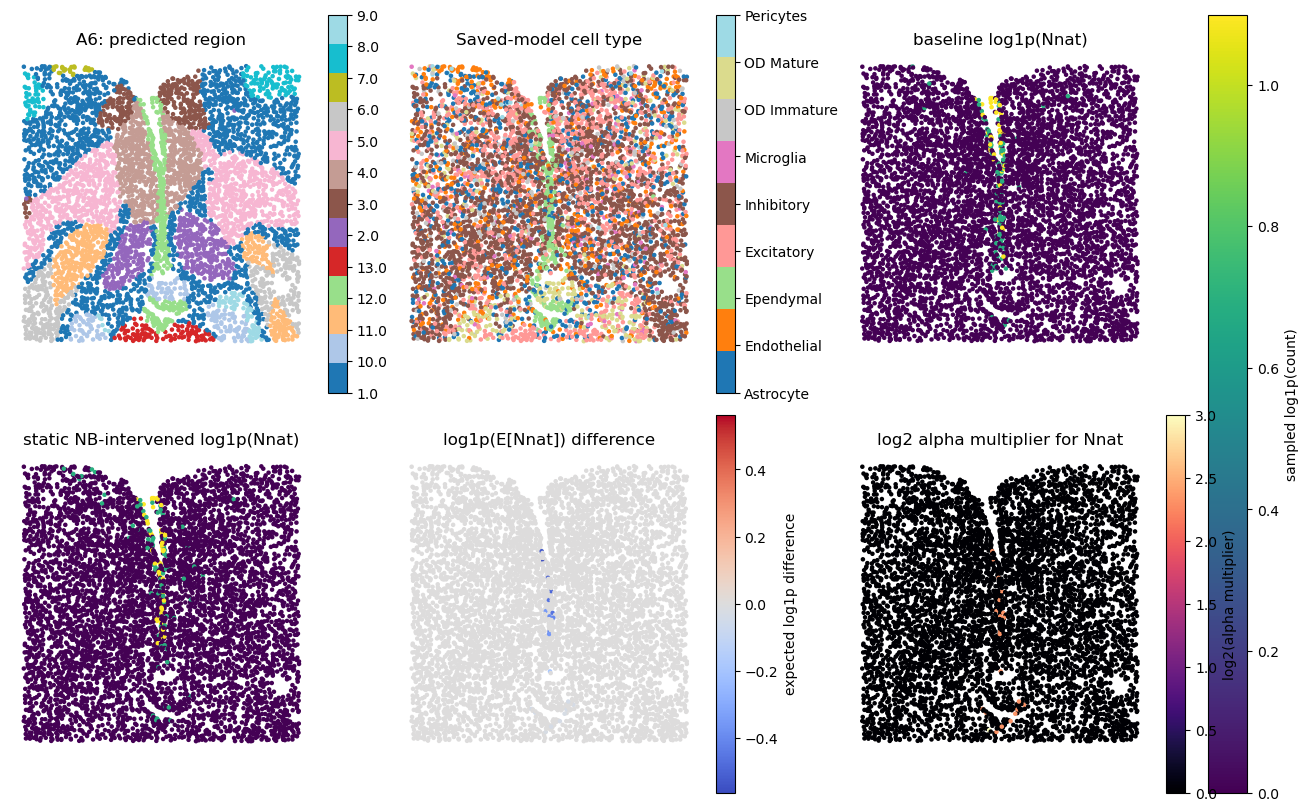

In [10]:
obs_static = pd.DataFrame(
    {
        "batch": TARGET_SLICE,
        "x": xyz[:, 0],
        "y": xyz[:, 1],
        "z": xyz[:, 2],
        "size": library_size,
        "pred_region": regions,
        "pred_celltype": pred_celltypes,
        f"mu_{PLOT_GENE}_baseline": mu_baseline_plot,
        f"mu_{PLOT_GENE}_static_intervened": mu_static_plot,
        f"alpha_{PLOT_GENE}_baseline": alpha_baseline_plot,
        f"alpha_{PLOT_GENE}_static_intervened": alpha_static_plot,
    },
    index=[
        f"{TARGET_SLICE}_cell_{i}"
        for i in range(len(xyz))
    ],
)

var = adata[:, genes].var.copy()

static_adata = ad.AnnData(
    X=csr_matrix(counts_static_intervened),
    obs=obs_static,
    var=var,
)

static_adata.layers["baseline_counts"] = csr_matrix(counts_baseline)
static_adata.layers["static_nb_intervened_counts"] = (
    csr_matrix(counts_static_intervened)
)
static_adata.obsm["spatial"] = xyz[:, :2].copy()
static_adata.obsm["spatial_3d"] = xyz.copy()
static_adata.obsm["pred_celltype_proba"] = (
    pred_celltype_probability.astype(np.float32)
)
static_adata.uns["celltype_sampling_seed"] = int(CELLTYPE_SAMPLING_SEED)
# Nested intervention dictionaries are stored as JSON strings because
# AnnData/HDF5 cannot reliably write heterogeneous list-of-dict objects.
static_adata.uns["static_mean_interventions"] = serialize_uns_metadata(
    STATIC_MEAN_INTERVENTIONS
)
static_adata.uns["static_dispersion_interventions"] = serialize_uns_metadata(
    STATIC_DISPERSION_INTERVENTIONS
)

static_adata.write_h5ad(
    OUT_DIR / f"{TARGET_SLICE}_static_nb_intervention.h5ad"
)

plot_gene_index = genes.index(PLOT_GENE)

log_baseline = np.log1p(counts_baseline[:, plot_gene_index])
log_static = np.log1p(counts_static_intervened[:, plot_gene_index])
log_mu_diff = (
    np.log1p(mu_static_plot)
    - np.log1p(mu_baseline_plot)
)
alpha_multiplier = (
    alpha_static_plot
    / np.maximum(alpha_baseline_plot, 1e-8)
)

region_levels = sorted(pd.unique(regions))
cell_levels = sorted(pd.unique(pred_celltypes))

expression_vmax = max(
    float(
        np.percentile(
            np.r_[log_baseline, log_static],
            99.5,
        )
    ),
    np.log1p(2),
)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(13, 8),
    constrained_layout=True,
)

region_scatter = axes[0, 0].scatter(
    xyz[:, 0],
    xyz[:, 1],
    c=pd.Categorical(
        regions,
        categories=region_levels,
    ).codes,
    s=5,
    cmap=ListedColormap(
        plt.cm.tab20(
            np.linspace(0, 1, len(region_levels))
        )
    ),
)

cell_scatter = axes[0, 1].scatter(
    xyz[:, 0],
    xyz[:, 1],
    c=pd.Categorical(
        pred_celltypes,
        categories=cell_levels,
    ).codes,
    s=5,
    cmap=ListedColormap(
        plt.cm.tab20(
            np.linspace(0, 1, len(cell_levels))
        )
    ),
)

base_expr = axes[0, 2].scatter(
    xyz[:, 0],
    xyz[:, 1],
    c=log_baseline,
    s=5,
    cmap="viridis",
    vmin=0,
    vmax=expression_vmax,
)

axes[1, 0].scatter(
    xyz[:, 0],
    xyz[:, 1],
    c=log_static,
    s=5,
    cmap="viridis",
    vmin=0,
    vmax=expression_vmax,
)

diff_abs = max(
    float(np.max(np.abs(log_mu_diff))),
    1e-6,
)

diff_scatter = axes[1, 1].scatter(
    xyz[:, 0],
    xyz[:, 1],
    c=log_mu_diff,
    s=5,
    cmap="coolwarm",
    vmin=-diff_abs,
    vmax=diff_abs,
)

alpha_scatter = axes[1, 2].scatter(
    xyz[:, 0],
    xyz[:, 1],
    c=np.log2(alpha_multiplier),
    s=5,
    cmap="magma",
)

axes[0, 0].set_title(f"{TARGET_SLICE}: predicted region")
axes[0, 1].set_title("Saved-model cell type")
axes[0, 2].set_title(f"baseline log1p({PLOT_GENE})")
axes[1, 0].set_title(f"static NB-intervened log1p({PLOT_GENE})")
axes[1, 1].set_title(f"log1p(E[{PLOT_GENE}]) difference")
axes[1, 2].set_title(f"log2 alpha multiplier for {PLOT_GENE}")

for axis in axes.ravel():
    axis.set_aspect("equal")
    axis.invert_yaxis()
    axis.axis("off")

region_bar = fig.colorbar(
    region_scatter,
    ax=axes[0, 0],
    ticks=np.arange(len(region_levels)),
)
region_bar.ax.set_yticklabels(region_levels)

cell_bar = fig.colorbar(
    cell_scatter,
    ax=axes[0, 1],
    ticks=np.arange(len(cell_levels)),
)
cell_bar.ax.set_yticklabels(cell_levels)

fig.colorbar(
    base_expr,
    ax=[axes[0, 2], axes[1, 0]],
    label="sampled log1p(count)",
)
fig.colorbar(
    diff_scatter,
    ax=axes[1, 1],
    label="expected log1p difference",
)
fig.colorbar(
    alpha_scatter,
    ax=axes[1, 2],
    label="log2(alpha multiplier)",
)

plt.savefig(
    OUT_DIR / f"{TARGET_SLICE}_static_nb_intervention.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()


## 11. Time-series intervention: define $\mu_i(t)$ and sample expression over time

The time-varying mean parameter is

$$
\log \mu_{ig}(t)
=
\log L_i
+
X_i^\top \widehat\beta_g
+
\Delta_{ig}(t).
$$

For a selected intervention rule,

$$
\Delta_{ig}(t)
=
\log(\mathrm{final\ fold\ change}) h(t),
$$

where $h(t)$ can be linear, quadratic, sigmoid, or transient.

In [11]:
counts_by_time = {}
mu_plot_by_time = {}
alpha_plot_by_time = {}

for time_index, t in enumerate(TIMES):
    counts_t = np.zeros(
        (len(xyz), len(genes)),
        dtype=np.int32,
    )
    mu_plot_t = np.zeros(len(xyz), dtype=float)
    alpha_plot_t = np.zeros(len(xyz), dtype=float)

    for j, gene in enumerate(genes):
        fit = gene_model["fits"].get(gene)

        if fit is None:
            continue

        beta = np.asarray(fit["beta"], dtype=float)
        alpha_base = max(float(fit["alpha"]), 1e-8)
        eta_base = X_baseline @ beta + offset

        eta_t, alpha_t = apply_time_nb_intervention(
            gene=gene,
            eta_base=eta_base,
            alpha_base=alpha_base,
            celltypes=pred_celltypes,
            regions=regions,
            t=float(t),
        )

        mu_t = np.exp(np.clip(eta_t, -20, 20))

        counts_t[:, j] = sample_negative_binomial(
            mu=mu_t,
            alpha=alpha_t,
            seed=SEED + 200000 + time_index * 1000 + j,
        )

        if gene == PLOT_GENE:
            mu_plot_t = mu_t.copy()
            alpha_plot_t = alpha_t.copy()

    counts_by_time[float(t)] = counts_t
    mu_plot_by_time[float(t)] = mu_plot_t
    alpha_plot_by_time[float(t)] = alpha_plot_t

## 12. Save the time-series synthetic data

Each time point is stored as a separate block of observations in one AnnData object. The same spatial coordinates are repeated across time, while the expected expression and sampled counts change through $\mu(t)$ and $\alpha(t)$.

In [12]:
time_obs_list = []
time_count_list = []
time_xyz_list = []

for t in TIMES:
    t = float(t)
    time_count_list.append(counts_by_time[t])
    time_xyz_list.append(xyz.copy())

    obs_t = pd.DataFrame(
        {
            "batch": TARGET_SLICE,
            "time": t,
            "x": xyz[:, 0],
            "y": xyz[:, 1],
            "z": xyz[:, 2],
            "size": library_size,
            "pred_region": regions,
            "pred_celltype": pred_celltypes,
            f"mu_{PLOT_GENE}_time": mu_plot_by_time[t],
            f"alpha_{PLOT_GENE}_time": alpha_plot_by_time[t],
        },
        index=[
            f"{TARGET_SLICE}_t{t:.2f}_cell_{i}"
            for i in range(len(xyz))
        ],
    )
    time_obs_list.append(obs_t)

time_counts = np.vstack(time_count_list)
time_obs = pd.concat(time_obs_list, axis=0)
time_xyz = np.vstack(time_xyz_list)

time_adata = ad.AnnData(
    X=csr_matrix(time_counts),
    obs=time_obs,
    var=var,
)

time_adata.layers["time_series_counts"] = time_adata.X.copy()
time_adata.obsm["spatial"] = time_xyz[:, :2].copy()
time_adata.obsm["spatial_3d"] = time_xyz.copy()
time_adata.uns["time_grid"] = TIMES.tolist()
time_adata.uns["celltype_sampling_seed"] = int(CELLTYPE_SAMPLING_SEED)
# Keep the complete intervention definitions in an HDF5-safe JSON form.
time_adata.uns["time_mean_interventions"] = serialize_uns_metadata(
    TIME_MEAN_INTERVENTIONS
)
time_adata.uns["time_dispersion_interventions"] = serialize_uns_metadata(
    TIME_DISPERSION_INTERVENTIONS
)

time_adata.write_h5ad(
    OUT_DIR / f"{TARGET_SLICE}_nb_mean_time_series.h5ad"
)


## 13. Summarize and plot the time-varying $\mu(t)$ effect

The line summary tracks the average expected expression across time. The spatial maps show how the expected expression pattern evolves as the NB mean parameter changes with time.

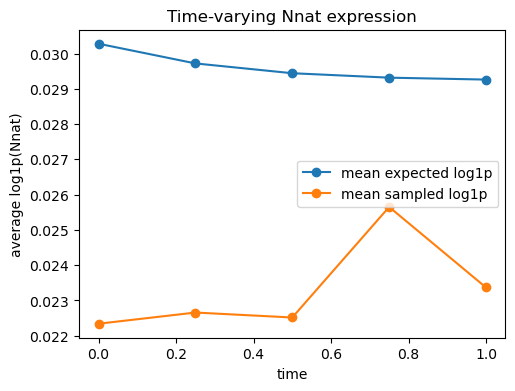

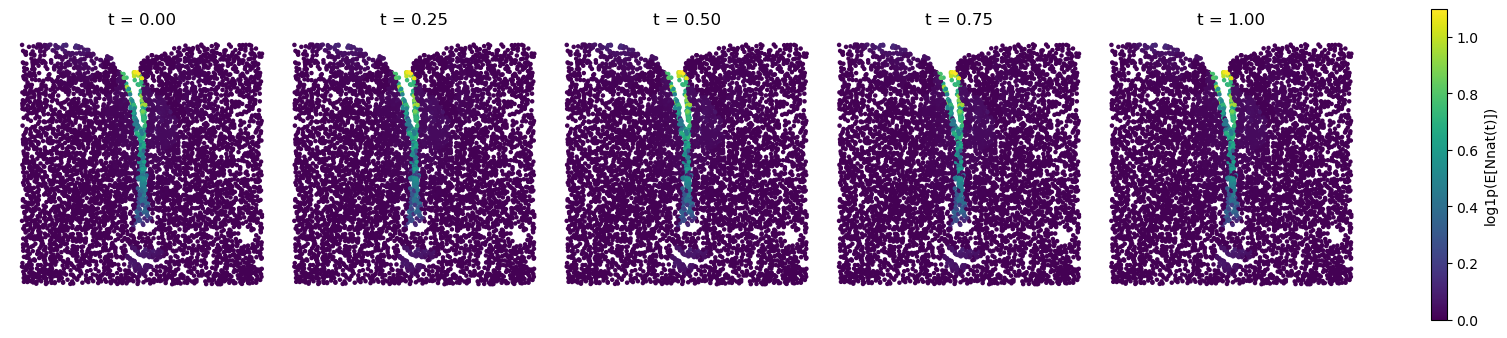

Saved outputs to: /Users/yyq/Documents/MyDocuments/project/吴浩老师 3d ST simulator/code/20260525 志伟源代码+原始数据/code_add_info/All_slices_prediction_outputs/A6_nb_intervention_time_series_v2
 time  mean_expected_log1p  mean_sampled_log1p   mean_alpha
 0.00             0.030279            0.022339 1.000000e-08
 0.25             0.029721            0.022656 1.000124e-08
 0.50             0.029443            0.022516 1.000333e-08
 0.75             0.029317            0.025650 1.000685e-08
 1.00             0.029262            0.023367 1.001276e-08


In [13]:
plot_gene_index = genes.index(PLOT_GENE)

summary_rows = []

for t in TIMES:
    t = float(t)

    summary_rows.append({
        "time": t,
        "mean_expected_log1p": float(
            np.mean(np.log1p(mu_plot_by_time[t]))
        ),
        "mean_sampled_log1p": float(
            np.mean(
                np.log1p(
                    counts_by_time[t][:, plot_gene_index]
                )
            )
        ),
        "mean_alpha": float(
            np.mean(alpha_plot_by_time[t])
        ),
    })

time_summary = pd.DataFrame(summary_rows)
time_summary.to_csv(
    OUT_DIR / f"{TARGET_SLICE}_{PLOT_GENE}_time_summary.csv",
    index=False,
)

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot(
    time_summary["time"],
    time_summary["mean_expected_log1p"],
    marker="o",
    label="mean expected log1p",
)
ax.plot(
    time_summary["time"],
    time_summary["mean_sampled_log1p"],
    marker="o",
    label="mean sampled log1p",
)
ax.set_xlabel("time")
ax.set_ylabel(f"average log1p({PLOT_GENE})")
ax.set_title(f"Time-varying {PLOT_GENE} expression")
ax.legend()
plt.savefig(
    OUT_DIR / f"{TARGET_SLICE}_{PLOT_GENE}_time_curve.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()

vmax_time = max(
    float(
        np.percentile(
            np.r_[
                *[
                    np.log1p(mu_plot_by_time[float(t)])
                    for t in TIMES
                ]
            ],
            99.5,
        )
    ),
    np.log1p(2),
)

fig, axes = plt.subplots(
    1,
    len(TIMES),
    figsize=(3.0 * len(TIMES), 3.3),
    constrained_layout=True,
)

for ax, t in zip(axes, TIMES):
    t = float(t)

    sc_map = ax.scatter(
        xyz[:, 0],
        xyz[:, 1],
        c=np.log1p(mu_plot_by_time[t]),
        s=5,
        cmap="viridis",
        vmin=0,
        vmax=vmax_time,
    )

    ax.set_title(f"t = {t:.2f}")
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.axis("off")

fig.colorbar(
    sc_map,
    ax=axes,
    label=f"log1p(E[{PLOT_GENE}(t)])",
)

plt.savefig(
    OUT_DIR / f"{TARGET_SLICE}_{PLOT_GENE}_time_series_maps.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()

print("Saved outputs to:", OUT_DIR.resolve())
print(time_summary.to_string(index=False))